In [2]:
import pandas as pd
import numpy as np
import seaborn as sns                       #visualisation
import matplotlib.pyplot as plt             #visualisation
%matplotlib inline     
sns.set(color_codes=True)

In [7]:
df = pd.read_csv("hotel_bookings.csv")
# To display the top 5 rows 
df.head(5)

,Unnamed: 0,hotel,is_canceled,lead_time,arrival_date_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,...,previous_bookings_not_canceled,assigned_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status
0,16303,City Hotel,1,67,May,0,3,2,0,0,...,0,A,0,No Deposit,0,Transient-Party,120.0,0,0,Canceled
1,17344,City Hotel,1,224,June,0,2,2,0,0,...,0,A,0,No Deposit,0,Transient,107.1,0,1,Canceled
2,4890,Resort Hotel,0,76,January,1,3,2,0,0,...,0,A,0,No Deposit,0,Transient,37.8,0,3,Check-Out
3,11142,Resort Hotel,0,72,July,0,2,2,0,0,...,0,D,0,No Deposit,0,Transient,162.0,1,1,Check-Out
4,18700,City Hotel,1,229,July,1,4,2,0,0,...,0,A,0,Non Refund,0,Transient,110.0,0,0,Canceled


In [4]:
df.dtypes

Unnamed: 0                          int64
hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_month                 object
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                            int64
babies                              int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
assigned_room_type                 object
booking_changes                     int64
deposit_type                       object
days_in_waiting_list                int64
customer_type                      object
adr                               float64
required_car_parking_spaces         int64
total_of_special_requests           int64
reservation_status                 object
dtype: object

In [8]:
df.shape

(408, 21)

In [9]:
df = df.drop(['hotel', 'arrival_date_month', 'assigned_room_type', 'deposit_type','reservation_status', 'customer_type'], axis=1)
df.head(5)

,Unnamed: 0,is_canceled,lead_time,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
0,16303,1,67,0,3,2,0,0,0,0,0,0,120.0,0,0
1,17344,1,224,0,2,2,0,0,0,0,0,0,107.1,0,1
2,4890,0,76,1,3,2,0,0,0,0,0,0,37.8,0,3
3,11142,0,72,0,2,2,0,0,0,0,0,0,162.0,1,1
4,18700,1,229,1,4,2,0,0,0,0,0,0,110.0,0,0


In [27]:
df.shape

(810, 11)

In [11]:
df = df.rename(columns={"is_canceled": "Canceled", "lead_time": "Lead Time", "stays_in_weekend_nights": "Weekend Nights", "stays_in_week_nights": "Week Nights", "adults": "Adults", "children": "Children", "babies": "Babies", "previous_cancellations": "Prev Cancelations", "previous_bookings_not_canceled": "Prev Bookings Not Canceled", "booking_changes": "Booking Changes", "days_in_waiting_list": "Waiting List Days", "adr": "Average Daily Rate", "required_car_parking_spaces": "Car parking", "total_of_special_requests": "Special Requests" })
df.head(5)

,Unnamed: 0,Canceled,Lead Time,Weekend Nights,Week Nights,Adults,Children,Babies,Prev Cancelations,Prev Bookings Not Canceled,Booking Changes,Waiting List Days,Address,Car parking,Special Requests
0,16303,1,67,0,3,2,0,0,0,0,0,0,120.0,0,0
1,17344,1,224,0,2,2,0,0,0,0,0,0,107.1,0,1
2,4890,0,76,1,3,2,0,0,0,0,0,0,37.8,0,3
3,11142,0,72,0,2,2,0,0,0,0,0,0,162.0,1,1
4,18700,1,229,1,4,2,0,0,0,0,0,0,110.0,0,0


In [12]:
duplicate_rows_df = df[df.duplicated()]
print("number of duplicate rows: ", duplicate_rows_df.shape)

number of duplicate rows:  (0, 15)


In [13]:
df.count()

Unnamed: 0                    408
Canceled                      408
Lead Time                     408
Weekend Nights                408
Week Nights                   408
Adults                        408
Children                      408
Babies                        408
Prev Cancelations             408
Prev Bookings Not Canceled    408
Booking Changes               408
Waiting List Days             408
Address                       408
Car parking                   408
Special Requests              408
dtype: int64

In [14]:
print(df.isnull().sum())

Unnamed: 0                    0
Canceled                      0
Lead Time                     0
Weekend Nights                0
Week Nights                   0
Adults                        0
Children                      0
Babies                        0
Prev Cancelations             0
Prev Bookings Not Canceled    0
Booking Changes               0
Waiting List Days             0
Address                       0
Car parking                   0
Special Requests              0
dtype: int64


In [15]:
df = df.drop_duplicates()
df.head(5)

,Unnamed: 0,Canceled,Lead Time,Weekend Nights,Week Nights,Adults,Children,Babies,Prev Cancelations,Prev Bookings Not Canceled,Booking Changes,Waiting List Days,Address,Car parking,Special Requests
0,16303,1,67,0,3,2,0,0,0,0,0,0,120.0,0,0
1,17344,1,224,0,2,2,0,0,0,0,0,0,107.1,0,1
2,4890,0,76,1,3,2,0,0,0,0,0,0,37.8,0,3
3,11142,0,72,0,2,2,0,0,0,0,0,0,162.0,1,1
4,18700,1,229,1,4,2,0,0,0,0,0,0,110.0,0,0


In [16]:
df = df.dropna()    # Dropping the missing values.
df.count()

Unnamed: 0                    408
Canceled                      408
Lead Time                     408
Weekend Nights                408
Week Nights                   408
Adults                        408
Children                      408
Babies                        408
Prev Cancelations             408
Prev Bookings Not Canceled    408
Booking Changes               408
Waiting List Days             408
Address                       408
Car parking                   408
Special Requests              408
dtype: int64

<Axes: xlabel='Lead Time'>

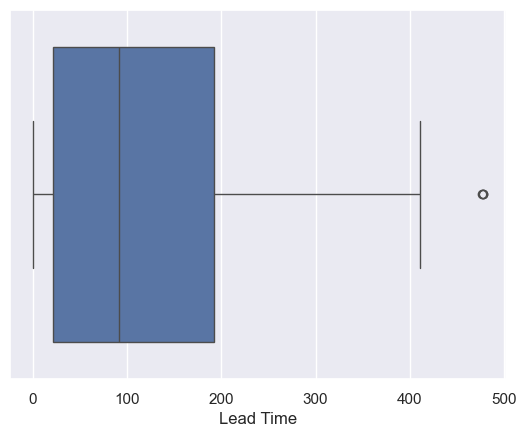

In [17]:
sns.boxplot(x=df['Lead Time'])

,Unnamed: 0,Canceled,Lead Time,Weekend Nights,Week Nights,Adults,Children,Babies,Prev Cancelations,Prev Bookings Not Canceled,Booking Changes,Waiting List Days,Address,Car parking,Special Requests
Unnamed: 0,1.000000,0.150178,0.173336,-0.098297,-0.127025,0.063958,-0.098710,-0.015220,-0.077412,-0.112714,-0.103322,-0.031669,0.168484,-0.055804,-0.005151
Canceled,0.150178,1.000000,0.369226,-0.017654,-0.085044,0.093277,-0.009867,-0.081694,-0.094114,-0.161391,-0.250835,-0.062151,0.131970,-0.364288,-0.107363
Lead Time,0.173336,0.369226,1.000000,0.312607,0.302394,0.081089,-0.018480,0.010646,-0.090316,-0.137614,-0.073202,0.039326,0.067191,-0.197716,-0.009372
Weekend Nights,-0.098297,-0.017654,0.312607,1.000000,0.671362,0.013483,0.003676,0.030238,-0.048501,-0.083505,0.025895,-0.006906,0.020910,-0.080733,-0.032322
Week Nights,-0.127025,-0.085044,0.302394,0.671362,1.000000,-0.005908,0.052534,-0.000108,-0.072028,-0.058524,0.066850,-0.001435,0.085535,-0.086922,-0.017356
Adults,0.063958,0.093277,0.081089,0.013483,-0.005908,1.000000,0.001295,0.035037,-0.151052,-0.213268,-0.112036,-0.092266,0.308353,0.010611,0.031103
Children,-0.098710,-0.009867,-0.018480,0.003676,0.052534,0.001295,1.000000,-0.035534,-0.026412,-0.037127,0.079436,-0.017442,0.218873,-0.013712,0.099503
Babies,-0.015220,-0.081694,0.010646,0.030238,-0.000108,0.035037,-0.035534,1.000000,-0.009222,-0.015815,0.185304,-0.006090,0.015220,0.040957,0.209129
Prev Cancelations,-0.077412,-0.094114,-0.090316,-0.048501,-0.072028,-0.151052,-0.026412,-0.009222,1.000000,0.461285,-0.032621,-0.004527,-0.083776,0.087421,0.054230
Prev Bookings Not Canceled,-0.112714,-0.161391,-0.137614,-0.083505,-0.058524,-0.213268,-0.037127,-0.015815,0.461285,1.000000,0.019096,-0.007763,-0.092843,0.175343,0.048772


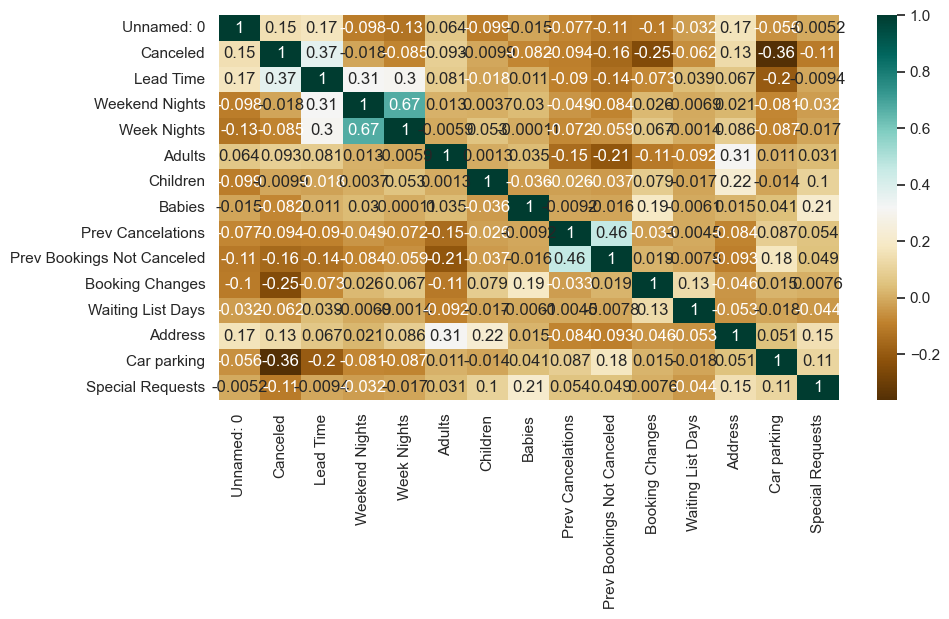

In [18]:
plt.figure(figsize=(10,5))
c= df.corr()
sns.heatmap(c,cmap="BrBG",annot=True)
c

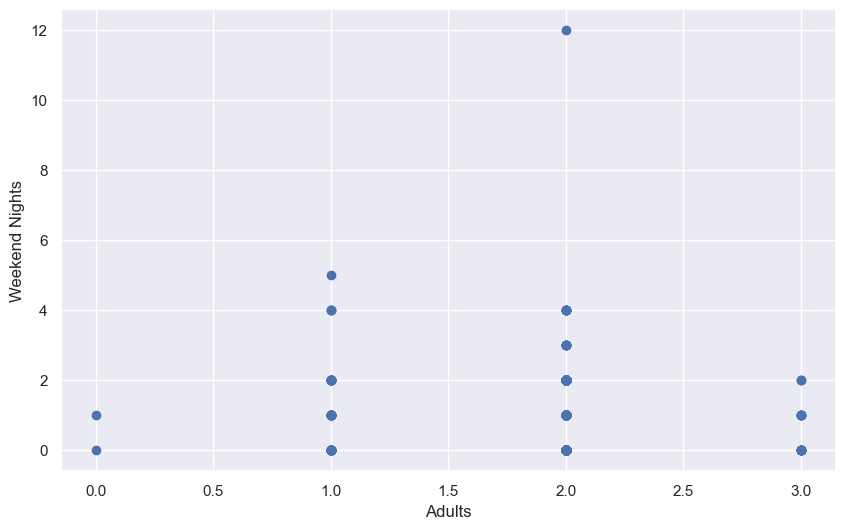

In [21]:
fig, ax = plt.subplots(figsize=(10,6))
ax.scatter(df['Adults'], df['Weekend Nights'])
ax.set_xlabel('Adults')
ax.set_ylabel('Weekend Nights')
plt.show()